# Jigsaw Puzzle Solver: End-to-End Reconstruction using Siamese Networks and Integer Linear Programming

This notebook demonstrates an end-to-end pipeline designed to automatically solve **4x4 jigsaw puzzles** (consisting of 16 individual tile images) using a combination of Deep Learning and Combinatorial Optimization.

### Pipeline Overview

1. **Data Loading & Preprocessing**: Loads puzzle tiles from disk, ensures color consistency (RGB conversion), and applies identical normalization (mean and standard deviation) used during model training.
2. **Siamese Neural Network (JigNet) Inference**: Performs pairwise evaluations on every potential directed combination of tiles. The model predicts the probability of one of five spatial relationships between any two tiles:
   * `No Match` (0)
   * `Left` (1)
   * `Right` (2)
   * `Up` (3)
   * `Down` (4)
3. **Pairwise Score Compilation**: Merges asymmetric edge predictions (e.g., *Tile B is Right of Tile A* and *Tile A is Left of Tile B*) to build symmetrical compatibility scores for all neighboring boundaries (`RIGHT` and `DOWN`).
4. **Integer Linear Programming (ILP)**: Models the final puzzle reconstruction as a constrained mathematical optimization problem using the `PuLP` library. The objective is to maximize the sum of spatial edge compatibility scores while strictly enforcing unique grid placements and preventing spatial overlaps.
5. **Visualization & Evaluation**: Stitches the solved tile configurations together and displays the reconstructed results side-by-side with the original reference image to evaluate pixel-wise matching accuracy.

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dependencies

In [ ]:
import sys
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
import shutil
import glob
import pulp
import seaborn as sns

### Accessing the JigNet Model
Initialize the system environment, import essential scientific and machine learning libraries, and append the project repository path to access custom modular Siamese Network classes (`JigNet`, `JigEncoder`).

In [ ]:
sys.path.append('/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model')

from jignet_models import JigNet, JigEncoder

**During inference, JigNet model expects to evaluate pairs of image tiles to predict their spatial relationships.**

## 1. Tile Tensor Specifications
**Each individual tile must be processed exactly like during training:**

*   Dimensions: Height and width of $128 \times 128$ pixels.
*   Color Channels: RGB format (3 channels).
*   Data Type: PyTorch float tensor (torch.float32).
*   Data Type: PyTorch float tensor (torch.float32).
*   Normalization: Subtracted by the training mean and divided by the training standard deviation
*   Final Shape: (3, 128, 128) for a single tile, and (B, 3, 128, 128) when batched.

## 2. Pairing Structure
Because JigNet is a Siamese Network, it accepts two inputs: tile_a and tile_b. If you have a $4 \times 4$ grid (16 tiles total), you should feed all potential combinations of adjacent tiles into the network to discover matching pairs.

**Class Label Definitions:**
*  0: No Match
*  1: tile_b is Left of tile_a
*  2: tile_b is Right of tile_a
*  3: tile_b is Up (Above) tile_a
*  4: tile_b is Down (Below) tile_a

### Solver Parameters
Define constants for puzzle grid setup, including tile count (16), grid dimensions (4x4), and the respective index positions of spatial relationships.

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/Jigsaw_Puzzle_Project/final_model/jignet_weights.pth'

csv_file = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/test_tiles.csv"

NUM_TILES = 16
GRID_SIZE = 4

NO_MATCH_IDX = 0
LEFT_IDX = 1
RIGHT_IDX = 2
UP_IDX = 3
DOWN_IDX = 4

# The same mean/std used for normalization in training
mean = [0.5452349781990051, 0.6246451139450073, 0.4715678095817566]
std = [0.23454082012176514, 0.19042210280895233, 0.21782392263412476]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model = JigNet(num_classes=5).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()

JigNet(
  (encoder): JigEncoder(
    (encoder): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): AdaptiveAvgPool2d(output_size=(2, 2))
      (13): Flatten(start_dim=1, end_dim=-1)
    )
  )
  (mlp): Sequent

### Preprocessing Transformations for Solver
We build the test transform pipeline that normalizes the input imagery to match the distribution expected by the neural network.

In [ ]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

**Helper function to get the 16 tikes for a specific image and store them in a dictionary**

In [ ]:
def get_tiles_dict(csv_path, target_img_id, img_id_col="img_id", tile_id_col="tile_id", path_col="tile_path"):
    """
    Reads the dataset metadata CSV file and maps each unique tile ID to its actual
    file path on disk for a specific target image ID.

    Args:
        csv_path (str): Path to the test_tiles metadata CSV file.
        target_img_id (str): The unique ID of the target jigsaw puzzle image.
        img_id_col (str): CSV column name containing the image IDs.
        tile_id_col (str): CSV column name containing the tile IDs.
        path_col (str): CSV column name containing file paths.

    Returns:
        dict: Dictionary mapping tile IDs (str) to their filesystem paths (str).
    """
    # Read the dataset CSV file containing tile listings
    df = pd.read_csv(csv_path)

    # Filter the rows matching the requested puzzle target image ID
    filtered_df = df[df[img_id_col] == target_img_id].copy()

    # Drop duplicates to isolate unique tiles
    unique_tiles = filtered_df[[tile_id_col, path_col]].drop_duplicates()

    # Assert sanity check that a complete 4x4 grid (16 tiles) exists
    assert len(unique_tiles) == 16, f"Expected 16 tiles, found {len(unique_tiles)} for image ID '{target_img_id}'."

    # Build the dictionary output
    tiles_dict = {}
    for _, row in unique_tiles.iterrows():
        tile_id = row[tile_id_col]
        tile_path = row[path_col]
        tiles_dict[tile_id] = tile_path

    return tiles_dict

**let's test the function**

In [ ]:
"""
target_img_id = "img_11"

tiles_dict = get_tiles_dict(csv_file, target_img_id, img_id_col="img_id", tile_id_col="tile_id", path_col="tile_path")

print(tiles_dict)
"""

{'tile_0_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_0_img_11.png', 'tile_1_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_1_img_11.png', 'tile_2_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_2_img_11.png', 'tile_3_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_3_img_11.png', 'tile_4_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_4_img_11.png', 'tile_5_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_5_img_11.png', 'tile_6_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_6_img_11.png', 'tile_7_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_7_img_11.png', 'tile_8_img_11': '/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/tiles/test/tile_8_img_11.png', 'tile_9_img_11': '

**Helper function to prepare each tile for the network**

In [ ]:
def load_and_preprocess_tile(tile_path):
    """
    Loads a puzzle tile from disk, transforms it from BGR to RGB format,
    and normalizes the image to prepare it for neural network inference.

    Args:
        tile_path (str): Filesystem path to the target tile PNG image.

    Returns:
        torch.Tensor: Preprocessed float32 tile tensor of shape (1, 3, 128, 128).
    """
    # Read the image file using OpenCV
    tile = cv2.imread(tile_path)
    if tile is None:
        raise FileNotFoundError(f"Could not load tile at: {tile_path}")

    # Convert color channel alignment from standard BGR (OpenCV) to RGB
    tile = cv2.cvtColor(tile, cv2.COLOR_BGR2RGB)

    # Apply tensor transformation pipeline and normalize using training mean/std
    tensor = preprocess(tile)

    # Add a batch dimension to match Siamese input architecture: (3, 128, 128) -> (1, 3, 128, 128)
    return tensor.unsqueeze(0)

**Helper fuction to run inference for a pair of tiles**

In [ ]:
def predict_relation(tile_path_a, tile_path_b, model, device):
    """
    Performs pairwise forward inference using the Siamese JigNet model to determine
    the spatial relative orientation between two discrete tiles.

    Args:
        tile_path_a (str): Path to the reference tile (Tile A).
        tile_path_b (str): Path to the candidate neighbor tile (Tile B).
        model (nn.Module): Trained JigNet network object.
        device (torch.device): Compute device (CPU or CUDA GPU).

    Returns:
        str: Predicted spatial relationship category class.
    """
    # Load and preprocess both input tiles independently
    t_a = load_and_preprocess_tile(tile_path_a).to(device)
    t_b = load_and_preprocess_tile(tile_path_b).to(device)

    # Evaluate the relationship without calculating gradients
    with torch.no_grad():
        logits = model(t_a, t_b)
        prediction = torch.argmax(logits, dim=1).item()

    # Map numerical predictions back to human-readable strings
    classes = {0: 'No Match', 1: 'Left', 2: 'Right', 3: 'Up', 4: 'Down'}
    return classes[prediction]

In [ ]:
df = pd.read_csv(csv_file)
tile_a_path = df['tile_path'].iloc[0]
tile_b_path = df['tile_path'].iloc[2]
relationship = predict_relation(tile_a_path, tile_b_path, loaded_model, device)
print(f"Spatial Relationship: {relationship}")

Spatial Relationship: No Match


**Generate `probs_matrix` a 3-dimensional NumPy array (`np.ndarray`) that stores the neural network's raw spatial relation probability predictions for every possible directed pairing of tiles in the jigsaw puzzle.**

### Shape
Its shape is exactly `(16, 16, 5)`(represented generally as `(NUM_TILES, NUM_TILES, 5)`):

*  First Dimension (`16`): The index $i$ of the first tile (`tile_a`).
*  Second Dimension (`16`): The index $j$ of the second tile (`tile_b`).
*  Third Dimension (`5`): The softmax probabilities for the 5 possible spatial relationship class labels predicted by the `JigNet` model.

### Slices (The 5 classes)
For any pair of tiles $(i, j)$ where $i \neq j$, `probs_matrix[i, j]` contains a 5-element vector `[P(0), P(1), P(2), P(3), P(4)]` representing:

*  `probs_matrix[i, j, 0]` (NO_MATCH_IDX): Probability that tile $j$ has no immediate neighbor relationship to tile $i$.
*  `probs_matrix[i, j, 1]` (LEFT_IDX): Probability that tile $j$ is to the Left of tile $i$.
*  `probs_matrix[i, j, 2]` (RIGHT_IDX): Probability that tile $j$ is to the Right of tile $i$.
*  `probs_matrix[i, j, 3]` (UP_IDX): Probability that tile $j$ is Above (Up) tile $i$.
*  `probs_matrix[i, j, 4]` (DOWN_IDX): Probability that tile $j$ is Below (Down) tile $i$.

(Note: Whenever $i == j$, the vector is initialized to zeros since a tile cannot be paired with itself.)

In [ ]:
def generate_probs_matrix_from_paths(csv_path, target_img_id, model, device):
    # 1. Retrieve the 16 tile paths from metadata
    tiles_dict = get_tiles_dict(csv_path, target_img_id, img_id_col="img_id", tile_id_col="tile_id", path_col="tile_path")

    # Ensure we sort the keys to keep tile ordering consistent (0 to 15)
    sorted_tile_keys = sorted(tiles_dict.keys(), key=lambda x: int(x.split('_')[1]) if isinstance(x, str) and '_' in x else int(x))
    tile_paths = [tiles_dict[k] for k in sorted_tile_keys]

    # 2. Initialize probs_matrix (16, 16, 5)
    probs_matrix = np.zeros((NUM_TILES, NUM_TILES, 5), dtype=np.float32)

    # 3. Double-loop to evaluate all directed pairs (i, j)
    for i in range(NUM_TILES):
        for j in range(NUM_TILES):
            if i == j:
                continue # No tile paired with itself

            path_a = tile_paths[i]
            path_b = tile_paths[j]

            # Load and preprocess both input tiles independently
            t_a = load_and_preprocess_tile(path_a).to(device)
            t_b = load_and_preprocess_tile(path_b).to(device)

            # Evaluate the relationship and get real continuous softmax probabilities
            with torch.no_grad():
                logits = model(t_a, t_b)
                probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

            # Store the actual probabilities instead of one-hot mapping
            probs_matrix[i, j] = probs

    return probs_matrix, sorted_tile_keys

In [ ]:
# Call the function to generate the probability matrix
target_img_id = "img_11"
probs_matrix, tile_ids = generate_probs_matrix_from_paths(csv_file, target_img_id, loaded_model, device)

# Map indices to human-readable relationship categories
relations = {0: 'No Match', 1: 'Left', 2: 'Right', 3: 'Up', 4: 'Down'}

print(f"=== Probability Matrix for {target_img_id} ===")
print(f"Shape: {probs_matrix.shape}\n")

# Print a highly readable summary of the non-zero predictions for each pair
print(f"{ 'Tile A':<10} | {'Tile B':<10} | {'Predicted Relation':<18} | {'Probability':<10}")
print("-" * 58)

printed_count = 0
for i in range(NUM_TILES):
    for j in range(NUM_TILES):
        if i == j:
            continue

        # Find which relation has the probability value 1.0 (since our function sets it to 1.0)
        prob_vector = probs_matrix[i, j]
        max_idx = np.argmax(prob_vector)
        max_val = prob_vector[max_idx]

        # Only print relationships that aren't 'No Match' to keep output clean and concise
        if max_idx != 0 and max_val > 0.0:
            tile_a_label = f"Tile {tile_ids[i].split('_')[1]}" if isinstance(tile_ids[i], str) else f"Tile {tile_ids[i]}"
            tile_b_label = f"Tile {tile_ids[j].split('_')[1]}" if isinstance(tile_ids[j], str) else f"Tile {tile_ids[j]}"
            print(f"{tile_a_label:<10} | {tile_b_label:<10} | {relations[max_idx]:<18} | {max_val:.1f}")
            printed_count += 1

if printed_count == 0:
    print("No active spatial neighbor relations were predicted by the network (all 'No Match').")

=== Probability Matrix for img_11 ===
Shape: (16, 16, 5)

Tile A     | Tile B     | Predicted Relation | Probability
----------------------------------------------------------
Tile 0     | Tile 1     | Right              | 1.0
Tile 0     | Tile 3     | Left               | 0.7
Tile 0     | Tile 4     | Down               | 1.0
Tile 1     | Tile 0     | Left               | 1.0
Tile 1     | Tile 2     | Right              | 1.0
Tile 1     | Tile 3     | Down               | 1.0
Tile 1     | Tile 5     | Down               | 1.0
Tile 2     | Tile 1     | Left               | 1.0
Tile 2     | Tile 3     | Right              | 1.0
Tile 2     | Tile 6     | Down               | 1.0
Tile 2     | Tile 11    | Down               | 0.7
Tile 3     | Tile 0     | Right              | 0.9
Tile 3     | Tile 1     | Up                 | 1.0
Tile 3     | Tile 2     | Left               | 1.0
Tile 3     | Tile 7     | Down               | 1.0
Tile 3     | Tile 9     | Up                 | 0.7
Tile 4  

### Symmetrical Score Compilation
Calculate symmetrical edge compatibility scores by averaging complementary predictions (e.g., tile B is to the right of A, and tile A is to the left of B).

For each tile, we generate a pair with the remaining 15 tiles then define the probability of RIGHT/LEFT and DOWN/UP

* (0, 1, RIGHT) = 1.0
* (0, 1, DOWN) = 0.0
* (0, 2, RIGHT) = 0.0
* (0, 2, DOWN) = 0.0
*  ....

In [ ]:
def build_pairwise_scores(probs_matrix):
  """Averages symmetric edge predictions to build the pairwise_scores dictionary."""
  pairwise_scores = {}

  for i in range(NUM_TILES):
    for j in range(NUM_TILES):
      if i == j:
        continue

      # Symmetrical RIGHT score: (Tile j is RIGHT of i) + (Tile i is LEFT of j)
      score_right = (
          probs_matrix[i, j, RIGHT_IDX] + probs_matrix[j, i, LEFT_IDX]
      ) / 2.0
      pairwise_scores[(i, j, 'RIGHT')] = float(score_right)

      # Symmetrical DOWN score: (Tile j is DOWN from i) + (Tile i is UP from j)
      score_down = (
          probs_matrix[i, j, DOWN_IDX] + probs_matrix[j, i, UP_IDX]
      ) / 2.0
      pairwise_scores[(i, j, 'DOWN')] = float(score_down)

  return pairwise_scores

In [ ]:
pairwise_scores = build_pairwise_scores(probs_matrix)
print(pairwise_scores)

{(0, 1, 'RIGHT'): 0.9910492300987244, (0, 1, 'DOWN'): 0.0006363627617247403, (0, 2, 'RIGHT'): 0.0025078593753278255, (0, 2, 'DOWN'): 4.0014651148112534e-08, (0, 3, 'RIGHT'): 9.012453006107535e-08, (0, 3, 'DOWN'): 2.915973891504109e-05, (0, 4, 'RIGHT'): 3.64061076207553e-13, (0, 4, 'DOWN'): 0.9945535659790039, (0, 5, 'RIGHT'): 9.781113696760713e-10, (0, 5, 'DOWN'): 0.0895581841468811, (0, 6, 'RIGHT'): 1.140919922150126e-15, (0, 6, 'DOWN'): 1.8621378883310058e-09, (0, 7, 'RIGHT'): 1.624783640963301e-10, (0, 7, 'DOWN'): 3.7635138061542506e-12, (0, 8, 'RIGHT'): 7.877249117882457e-06, (0, 8, 'DOWN'): 9.476399753793885e-08, (0, 9, 'RIGHT'): 3.872261018778023e-12, (0, 9, 'DOWN'): 2.435197876682338e-11, (0, 10, 'RIGHT'): 3.778798107756387e-11, (0, 10, 'DOWN'): 8.531173545378579e-10, (0, 11, 'RIGHT'): 8.88400984722093e-12, (0, 11, 'DOWN'): 4.905055561721383e-08, (0, 12, 'RIGHT'): 9.864297112471831e-08, (0, 12, 'DOWN'): 2.5281409317358047e-14, (0, 13, 'RIGHT'): 4.472298399671448e-12, (0, 13, 'DO

The `pairwise_scores` dictionary only needs to track '**RIGHT**' and '**DOWN**' relationships because of the way the 2D grid structure is defined mathematically in the ILP formulation.

Here is why this design is efficient and complete:

**1. Avoiding Double-Counting (Redundancy)**

In a 2D grid, any boundary edge between two adjacent cells is shared. For example, if **Tile B is to the RIGHT of Tile A**, that is the exact same physical arrangement as **Tile A being to the LEFT of Tile B**.

Tracking both `(A, B, 'RIGHT')` and `(B, A, 'LEFT')` would be redundant. By defining only '**RIGHT**' and '**DOWN**', we cover every single horizontal and vertical grid boundary edge exactly once:

*  All horizontal adjacencies are represented by `RIGHT` (Tile at column $c$ and Tile at column $c+1$).
*  All vertical adjacencies are represented by `DOWN` (Tile at row $r$ and Tile at row $r+1$).

### 10. Jigsaw Puzzle Reconstruction via ILP
Define the Integer Linear Programming formulation using PuLP. We define decision variables, objective constraints to prevent overlapping placements, and maximize overall edge compatibility.

In [ ]:
def solve_jigsaw_ilp(pairwise_scores):
    """Solves a 4x4 jigsaw puzzle using Integer Linear Programming (ILP).

    :param pairwise_scores: A dictionary mapping (i, j, 'RIGHT' or 'DOWN') to a
      float compatibility score.
                            - (i, j, 'RIGHT') is the score for tile j being to
                              the RIGHT of tile i.
                            - (i, j, 'DOWN') is the score for tile j being
                              BELOW tile i.
    :return: A 4x4 list of tile indices representing the reconstructed image.
    """

    # -------------------------------------------------------------------------
    # 1. INITIALIZE THE OPTIMIZATION PROBLEM
    # -------------------------------------------------------------------------
    # Create an optimization problem object aimed at maximizing our score
    prob = pulp.LpProblem("Jigsaw_Puzzle_Solver", pulp.LpMaximize)

    # Define fixed grid dimensions (4x4) and total tile count (16)
    NUM_TILES = 16  # Total number of tiles in a 4x4 puzzle
    ROWS = 4  # Total number of rows on the board
    COLS = 4  # Total number of columns on the board

    # -------------------------------------------------------------------------
    # 2. DEFINE DECISION VARIABLES
    # -------------------------------------------------------------------------
    # X[i, r, c] is a binary variable: 1 if tile i is placed at row r, column c; 0 otherwise
    X = pulp.LpVariable.dicts(
        "X",
        (
            (i, r, c)
            for i in range(NUM_TILES)
            for r in range(ROWS)
            for c in range(COLS)
        ),
        cat="Binary",  # Restricts the variable values strictly to {0, 1}
    )

    # H[i, j, r, c] is a binary variable: 1 if tile i is at (r,c) AND tile j is at (r, c+1); 0 otherwise
    H = pulp.LpVariable.dicts(
        "H",
        (
            (i, j, r, c)
            for i in range(NUM_TILES)
            for j in range(NUM_TILES)
            if i != j
            for r in range(ROWS)
            for c in range(COLS - 1)  # c goes up to 2 since c+1 must be <= 3
        ),
        cat="Binary",  # Restricts the variable values strictly to {0, 1}
    )

    # V[i, j, r, c] is a binary variable: 1 if tile i is at (r,c) AND tile j is at (r+1, c); 0 otherwise
    V = pulp.LpVariable.dicts(
        "V",
        (
            (i, j, r, c)
            for i in range(NUM_TILES)
            for j in range(NUM_TILES)
            if i != j
            for r in range(ROWS - 1)  # r goes up to 2 since r+1 must be <= 3
            for c in range(COLS)
        ),
        cat="Binary",  # Restricts the variable values strictly to {0, 1}
    )

    # -------------------------------------------------------------------------
    # 3. DEFINE THE OBJECTIVE FUNCTION
    # -------------------------------------------------------------------------
    # Initialize an empty list to accumulate the weighted objective terms
    objective_terms = []

    # Iterate over all horizontal edge placements to accumulate horizontal compatibility scores
    for i in range(NUM_TILES):  # Loop through all possible left tiles
        for j in range(NUM_TILES):  # Loop through all possible right tiles
            if i != j:  # A tile cannot be adjacent to itself
                # Fetch precomputed pairwise score for tile j to the RIGHT of tile i
                score_h = pairwise_scores.get((i, j, "RIGHT"), 0.0)
                for r in range(ROWS):  # Iterate over all rows
                    for c in range(COLS - 1):  # Iterate over valid horizontal left-columns
                        # Add (score * binary variable) to objective function terms
                        objective_terms.append(score_h * H[i, j, r, c])

    # Iterate over all vertical edge placements to accumulate vertical compatibility scores
    for i in range(NUM_TILES):  # Loop through all possible top tiles
        for j in range(NUM_TILES):  # Loop through all possible bottom tiles
            if i != j:  # A tile cannot be adjacent to itself
                # Fetch precomputed pairwise score for tile j BELOW tile i
                score_v = pairwise_scores.get((i, j, "DOWN"), 0.0)
                for r in range(ROWS - 1):  # Iterate over valid vertical top-rows
                    for c in range(COLS):  # Iterate over all columns
                        # Add (score * binary variable) to objective function terms
                        objective_terms.append(score_v * V[i, j, r, c])

    # Set the summation of all score-weighted edge variables as the objective to maximize
    prob += pulp.lpSum(objective_terms), "Maximize_Total_Edge_Compatibility_Score"

    # -------------------------------------------------------------------------
    # 4. DEFINE HARD STRUCTURAL CONSTRAINTS
    # -------------------------------------------------------------------------

    # Constraint 1: Exactly one tile must be assigned to each grid cell (r, c)
    for r in range(ROWS):  # Loop through every row on the grid
        for c in range(COLS):  # Loop through every column on the grid
            # Sum of all tile assignments at cell (r, c) must equal 1
            prob += (
                pulp.lpSum(X[i, r, c] for i in range(NUM_TILES)) == 1,
                f"One_Tile_Per_Cell_r{r}_c{c}",
            )

    # Constraint 2: Each tile i must be assigned to exactly one cell (r, c) on the board
    for i in range(NUM_TILES):  # Loop through every tile
        # Sum of cell assignments across the entire grid for tile i must equal 1
        prob += (
            pulp.lpSum(
                X[i, r, c] for r in range(ROWS) for c in range(COLS))== 1,
                f"One_Cell_Per_Tile_i{i}",
        )

    # Constraint 3: Linearize AND relationship for horizontal adjacent variables (H[i, j, r, c] == X[i, r, c] AND X[j, r, c+1])
    for i in range(NUM_TILES):  # Loop through left tile candidates
        for j in range(NUM_TILES):  # Loop through right tile candidates
            if i != j:  # Skip identical tile comparisons
                for r in range(ROWS):  # Loop through all rows
                    for c in range(COLS - 1):  # Loop through left-column cells
                        # H[i, j, r, c] can only be 1 if tile i is at (r, c)
                        prob += (
                            H[i, j, r, c] <= X[i, r, c],
                            f"H_link_left_i{i}_j{j}_r{r}_c{c}",
                        )
                        # H[i, j, r, c] can only be 1 if tile j is at (r, c+1)
                        prob += (
                            H[i, j, r, c] <= X[j, r, c + 1],
                            f"H_link_right_i{i}_j{j}_r{r}_c{c}",
                        )
                        # H[i, j, r, c] must be 1 if BOTH tile i is at (r, c) AND tile j is at (r, c+1)
                        prob += (
                            H[i, j, r, c]
                            >= X[i, r, c] + X[j, r, c + 1] - 1,
                            f"H_link_both_i{i}_j{j}_r{r}_c{c}",
                        )

    # Constraint 4: Linearize AND relationship for vertical adjacent variables (V[i, j, r, c] == X[i, r, c] AND X[j, r+1, c])
    for i in range(NUM_TILES):  # Loop through top tile candidates
        for j in range(NUM_TILES):  # Loop through bottom tile candidates
            if i != j:  # Skip identical tile comparisons
                for r in range(ROWS - 1):  # Loop through top-row cells
                    for c in range(COLS):  # Loop through all columns
                        # V[i, j, r, c] can only be 1 if tile i is at (r, c)
                        prob += (
                            V[i, j, r, c] <= X[i, r, c],
                            f"V_link_top_i{i}_j{j}_r{r}_c{c}",
                        )
                        # V[i, j, r, c] can only be 1 if tile j is at (r+1, c)
                        prob += (
                            V[i, j, r, c] <= X[j, r + 1, c],
                            f"V_link_bottom_i{i}_j{j}_r{r}_c{c}",
                        )
                        # V[i, j, r, c] must be 1 if BOTH tile i is at (r, c) AND tile j is at (r+1, c)
                        prob += (
                            V[i, j, r, c]
                            >= X[i, r, c] + X[j, r + 1, c] - 1,
                            f"V_link_both_i{i}_j{j}_r{r}_c{c}",
                        )

    # -------------------------------------------------------------------------
    # 5. SOLVE THE OPTIMIZATION MODEL
    # -------------------------------------------------------------------------
    # Execute the default CBC ILP solver silently without verbose logging output
    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    status = pulp.LpStatus[prob.status]

    print(f"ILP status: {status}")

    if status != "Optimal":
      raise RuntimeError(f"ILP did not find an optimal solution. Status: {status}")

    # -------------------------------------------------------------------------
    # 6. EXTRACT AND RETURN THE SOLUTION
    # -------------------------------------------------------------------------
    # Initialize a 4x4 grid filled with zeros to store the solved tile placement indices
    reconstructed_board = [[0 for _ in range(COLS)] for _ in range(ROWS)]

    # Loop through all decision variable combinations to read the solver output
    for i in range(NUM_TILES):  # Loop through each tile index
        for r in range(ROWS):  # Loop through each row index
            for c in range(COLS):  # Loop through each column index
                # Check if the solver set this specific placement variable to 1
                if pulp.value(X[i, r, c]) == 1.0:
                    # Place tile index i into its assigned row r and column c in our grid
                    reconstructed_board[r][c] = i

    # Return the assembled 4x4 matrix of tile indices
    return reconstructed_board

### Plotting Puzzle Grid Results
Define a utility to stitch the reconstructed tiles horizontally and vertically based on the ILP solution, and plot it alongside the original reference image.

In [ ]:
def display_reconstructed_and_original(reconstructed_board, tile_ids, csv_path, target_image_id):
  """Reconstructs the full jigsaw grid from tile paths, loads the original image
  from images_splits.csv, displays both side-by-side, and returns the reconstructed image.
  """
  # 1. Retrieve the mapping of tile IDs to their actual image file paths
  tiles_dict = get_tiles_dict(csv_path, target_image_id, img_id_col="img_id", tile_id_col="tile_id", path_col="tile_path")

  rows, cols = len(reconstructed_board), len(reconstructed_board[0])

  # 2. Build the reconstructed image array by stitching individual tiles
  board_rows = []
  for r in range(rows):
    row_tiles = []
    for c in range(cols):
      # Map board value (index in tile_ids) to the actual tile string
      tile_index = reconstructed_board[r][c]
      actual_tile_id = tile_ids[tile_index]
      tile_path = tiles_dict[actual_tile_id]

      if not os.path.exists(tile_path):
        raise FileNotFoundError(f"Tile image not found at: {tile_path}")

      # Load tile image and convert BGR -> RGB
      img_bgr = cv2.imread(tile_path)
      img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
      row_tiles.append(img_rgb)

    # Concatenate tiles horizontally across columns
    board_rows.append(np.hstack(row_tiles))

  # Concatenate rows vertically to form the complete reconstructed image
  reconstructed_img = np.vstack(board_rows)

  # 3. Retrieve original image path from the splits metadata
  orig_path = None
  if os.path.exists(images_splits):
    splits_df = pd.read_csv(images_splits)
    image_df = splits_df[splits_df["image_id"] == target_image_id]
    if not image_df.empty and "image_path" in image_df.columns:
      orig_path = image_df["image_path"].iloc[0]

  # 4. Plot both images side-by-side
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))

  # Plot Reconstructed Image
  axes[0].imshow(reconstructed_img)
  axes[0].set_title(f"Reconstructed Image\nID: {target_image_id}")
  axes[0].axis("off")

  # Plot Original Image
  if orig_path and os.path.exists(orig_path):
    orig_img = cv2.imread(orig_path)
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    axes[1].imshow(orig_img_rgb)
    axes[1].set_title(f"Original Image\nID: {target_image_id}")
  else:
    axes[1].imshow(reconstructed_img)
    axes[1].set_title(f"Original Path Not Found\n(Showing Grid Output)")

  axes[1].axis("off")

  plt.tight_layout()
  plt.show()

  # Return the reconstructed array so we can use it directly for comparison
  return reconstructed_img


In [ ]:
def compare_images(img1, img2):
  # 1. Compare shapes
  shape_original = img1.shape
  shape_reconstructed = img2.shape

  print(f"Shape of original image: {shape_original}")
  print(f"Shape of reconstructed image: {shape_reconstructed}")

  if shape_original == shape_reconstructed:
    print("Image shapes are identical.")

    # 2. Compare pixel-wise if shapes are the same
    are_equal_pixels = np.array_equal(img1, img2)

    if are_equal_pixels:
        print("Images are pixel-wise identical.")
    else:
        print("Images have the same shape but are not pixel-wise identical.")
        # You can also find where they differ
        diff_pixels = np.sum(img1 != img2)
        print(f"Number of differing pixels: {diff_pixels}")
  else:
    print("Image shapes are different, so they cannot be pixel-wise identical.")

Selected 10 random image IDs: ['img_205', 'img_7', 'img_410', 'img_112', 'img_175', 'img_634', 'img_341', 'img_487', 'img_210', 'img_91']

 PROCESSING IMAGE 1/10: img_205
ILP status: Optimal


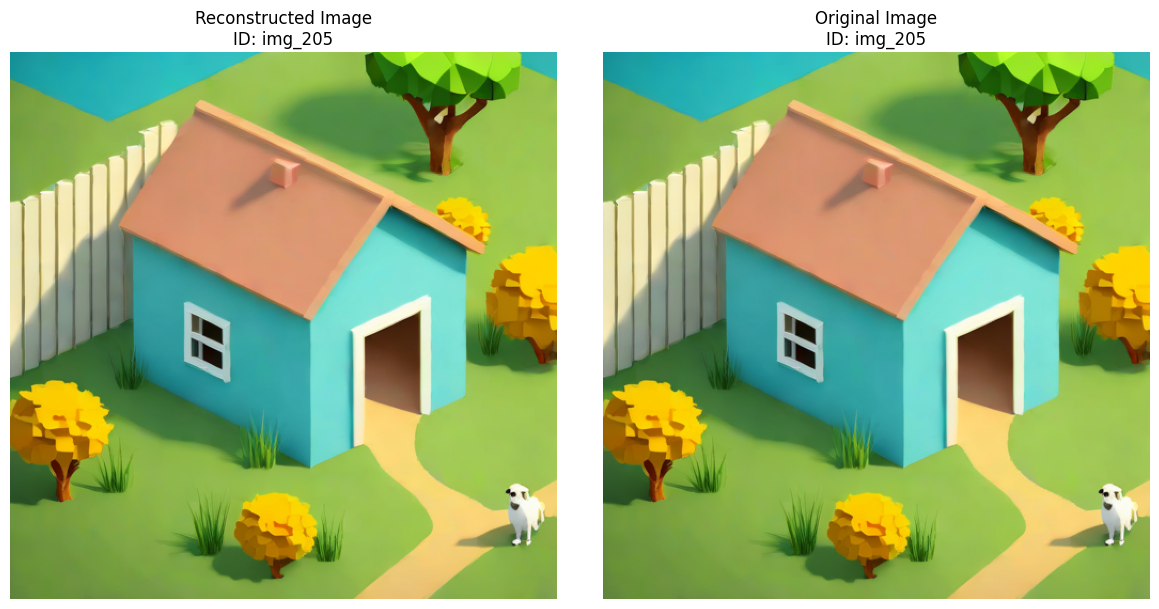

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.


 PROCESSING IMAGE 2/10: img_7
ILP status: Optimal


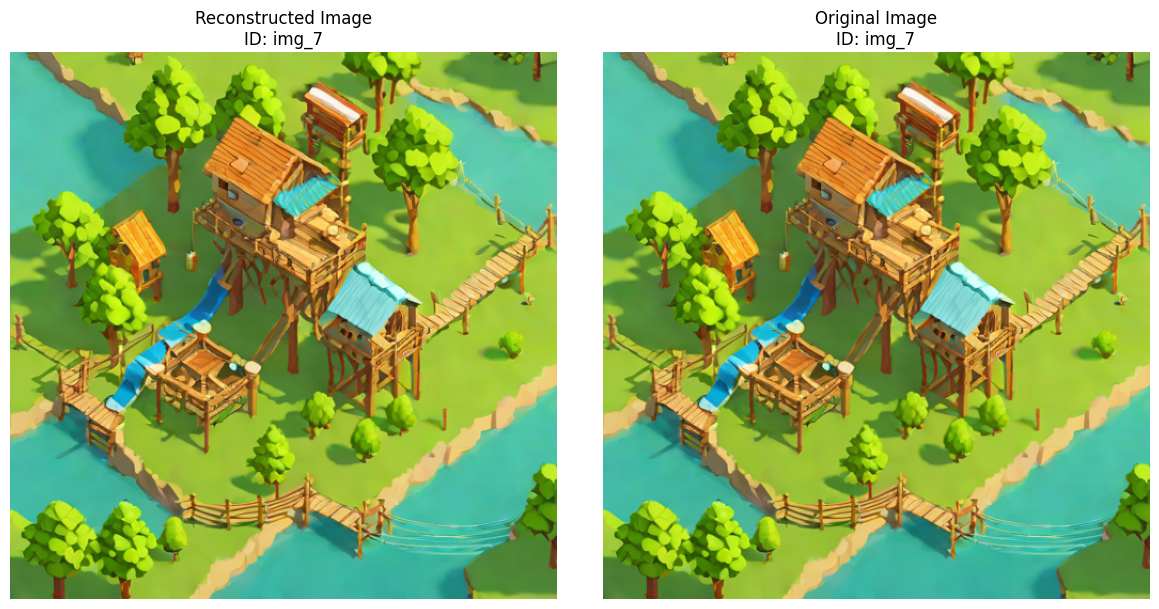

Shape of original image: (512, 512, 3)
Shape of reconstructed image: (512, 512, 3)
Image shapes are identical.
Images are pixel-wise identical.


 PROCESSING IMAGE 3/10: img_410


In [ ]:
# csv file to access the image_path
images_splits = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/images_splits.csv"
# csv file to access tiles
tiles_csv = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/test_tiles.csv"

# 1. Load the dataset CSVs to find unique image IDs and map splits
tiles_df = pd.read_csv(tiles_csv)
splits_df = pd.read_csv(images_splits)

# Extract all unique image IDs available in the tiles dataset
unique_images = tiles_df["img_id"].unique()

# Choose 10 random image IDs
random.seed(42)  # Optional seed for reproducibility
sampled_images = random.sample(list(unique_images), 10)

print(f"Selected 10 random image IDs: {sampled_images}\n")

# 2. Iterate and process each image ID through the full solver & evaluation pipeline
for idx, target_id in enumerate(sampled_images, 1):
    print(f"===================================================")
    print(f" PROCESSING IMAGE {idx}/10: {target_id}")
    print(f"===================================================")

    # Generate relation probability matrix from Siamese network
    probs_matrix, tile_ids = generate_probs_matrix_from_paths(
        csv_path=tiles_csv,
        target_img_id=target_id,
        model=loaded_model,
        device=device
    )

    # Compile symmetrical compatibility scores for vertical and horizontal adjacencies
    pairwise_scores = build_pairwise_scores(probs_matrix)

    # Optimize tile configurations via the ILP solver
    reconstructed_board = solve_jigsaw_ilp(pairwise_scores)

    # Display side-by-side and capture stitched reconstructed RGB array
    reconstructed_img = display_reconstructed_and_original(
        reconstructed_board=reconstructed_board,
        tile_ids=tile_ids,
        csv_path=tiles_csv,
        target_image_id=target_id
    )

    # Retrieve reference path to compare pixel accuracy
    target_row = splits_df[splits_df["image_id"] == target_id]
    if not target_row.empty:
        orig_path = target_row["image_path"].iloc[0]
        if os.path.exists(orig_path):
            original_img = cv2.imread(orig_path)
            original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

            # Compare original reference vs our solved array
            compare_images(original_img_rgb, reconstructed_img)
        else:
            print(f"[Error] Original image file missing at: {orig_path}")
    else:
        print(f"[Error] Target image ID {target_id} not found in images_splits.csv")
    print("\n")

In [ ]:
# csv file to access the image_path
images_splits = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/images_splits.csv"
# csv file to access tiles
tiles_csv = "/content/drive/MyDrive/Jigsaw_Puzzle_Project/jigsaw_dataset/metadata/test_tiles.csv"

def reconstruct_board_to_image(reconstructed_board, tile_ids, csv_path, target_image_id):
    """Silently reconstructs the full jigsaw grid from tile paths as a single NumPy array without plotting."""
    tiles_dict = get_tiles_dict(csv_path, target_image_id, img_id_col="img_id", tile_id_col="tile_id", path_col="tile_path")
    rows, cols = len(reconstructed_board), len(reconstructed_board[0])

    board_rows = []
    for r in range(rows):
      row_tiles = []
      for c in range(cols):
        tile_index = reconstructed_board[r][c]
        actual_tile_id = tile_ids[tile_index]
        tile_path = tiles_dict[actual_tile_id]

        if not os.path.exists(tile_path):
          raise FileNotFoundError(f"Tile image not found at: {tile_path}")

        img_bgr = cv2.imread(tile_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        row_tiles.append(img_rgb)
      board_rows.append(np.hstack(row_tiles))

    return np.vstack(board_rows)

# 1. Load dataset CSVs
tiles_df = pd.read_csv(tiles_csv)
splits_df = pd.read_csv(images_splits)

# Extract all unique image IDs available in the tiles dataset
all_unique_images = tiles_df["img_id"].unique()
total_images = len(all_unique_images)
successful_reconstructions = 0

print(f"Starting solver evaluation on all {total_images} images...\n")

# 2. Iterate and process each image ID through the solver & evaluation pipeline
for idx, target_id in enumerate(all_unique_images, 1):
    try:
        # Generate relation probability matrix from Siamese network
        probs_matrix, tile_ids = generate_probs_matrix_from_paths(
            csv_path=tiles_csv,
            target_img_id=target_id,
            model=loaded_model,
            device=device
        )

        # Compile symmetrical compatibility scores
        pairwise_scores = build_pairwise_scores(probs_matrix)

        # Optimize tile configurations via the ILP solver
        reconstructed_board = solve_jigsaw_ilp(pairwise_scores)

        # Stitch reconstructed RGB array without plotting
        reconstructed_img = reconstruct_board_to_image(
            reconstructed_board=reconstructed_board,
            tile_ids=tile_ids,
            csv_path=tiles_csv,
            target_image_id=target_id
        )

        # Retrieve original image path and compare
        target_row = splits_df[splits_df["image_id"] == target_id]
        if not target_row.empty:
            orig_path = target_row["image_path"].iloc[0]
            if os.path.exists(orig_path):
                original_img = cv2.imread(orig_path)
                original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

                # Verify image shapes and perform pixel-wise matching
                if original_img_rgb.shape == reconstructed_img.shape:
                    if np.array_equal(original_img_rgb, reconstructed_img):
                        successful_reconstructions += 1
                        print(f"[{idx}/{total_images}] Image {target_id}: SUCCESS (Perfect reconstruction)")
                    else:
                        print(f"[{idx}/{total_images}] Image {target_id}: FAILED (Mismatching pixels)")
                else:
                    print(f"[{idx}/{total_images}] Image {target_id}: FAILED (Mismatching shapes)")
            else:
                print(f"[{idx}/{total_images}] Image {target_id}: FAILED (Original file missing)")
        else:
            print(f"[{idx}/{total_images}] Image {target_id}: FAILED (ID not found in images_splits.csv)")
    except Exception as e:
        print(f"[{idx}/{total_images}] Image {target_id}: ERROR ({str(e)})")

# 3. Calculate and display total accuracy
accuracy = (successful_reconstructions / total_images) * 100
print("\n=========================================")
print(" EVALUATION COMPLETED")
print("=========================================")
print(f"Total evaluated images: {total_images}")
print(f"Successful reconstructions: {successful_reconstructions}")
print(f"Solver Accuracy: {accuracy:.2f}%")